In [6]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def swissRoll(samples=1024, noise=0.5):
    t = 1.5 * 3.14 * (1 + 2 * tf.random.uniform((samples, 1)))
    x = t * tf.math.cos(t)
    y = t * tf.math.sin(t)
    X = tf.concat([x, y], axis=1)
    if noise > 0:
        X += noise * tf.random.normal(shape=(samples, 2))
    return X


In [56]:
batches = 100
batch_size = 1024

normal_dist = tf.random.normal((batches * batch_size, 2))
swiss_roll_dist = swissRoll(samples=batches * batch_size)

# Naive

In [30]:
naive_model = tf.keras.models.Sequential()
naive_model.add(tf.keras.layers.InputLayer(input_shape=(2,)))
naive_model.add(tf.keras.layers.Dense(64, activation="relu"))
naive_model.add(tf.keras.layers.BatchNormalization())
naive_model.add(tf.keras.layers.Dense(64, activation="relu"))
naive_model.add(tf.keras.layers.Dense(64, activation="relu"))
naive_model.add(tf.keras.layers.Dense(64, activation="relu"))
naive_model.add(tf.keras.layers.Dense(2, activation="linear"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/input_layer.py:27: UserWarning: Argument `input_shape` is deprecated. Use `shape` instead.
  warnings.warn(


In [ ]:
naive_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")
naive_model.fit(normal_dist, swiss_roll_dist, epochs=100, batch_size=batch_size)

Epoch 1/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 46.5767
Epoch 2/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.4389
Epoch 3/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.4364
Epoch 4/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.4272
Epoch 5/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46.4283
Epoch 6/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46.4197
Epoch 7/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46.4234
Epoch 8/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.4246
Epoch 9/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 46.4218
Epoch 10/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 46.4193
Epoch 11/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 46.4199
Epoch 12/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 46.4146
Epoch 13/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 46.4178
Epoch 14/100
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 46.4160
Epoch 15/100
100/100 ━━━━━━━━

In [ ]:
pred = naive_model.predict(normal_dist)

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 3s 980us/step


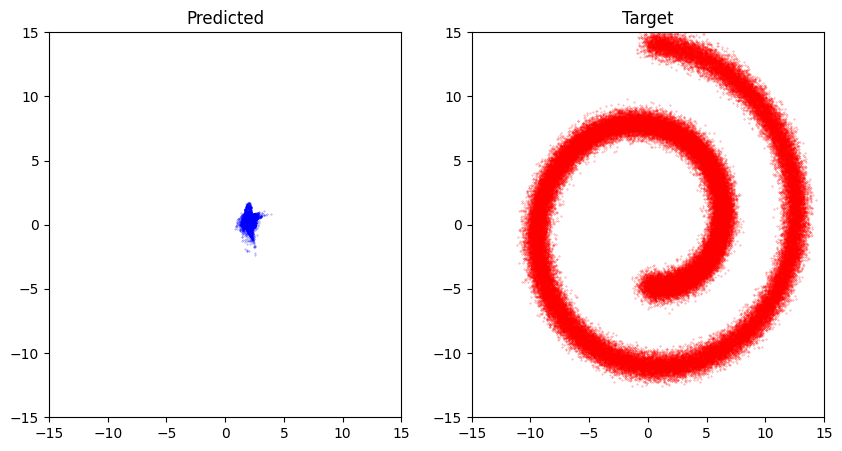

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(pred[:, 0], pred[:, 1], color="blue", alpha=0.5, s=0.1)
ax[0].set_xlim(-15, 15)
ax[0].set_ylim(-15, 15)
ax[0].set_title("Predicted")
ax[1].scatter(swiss_roll_dist[:, 0], swiss_roll_dist[:, 1], color="red", alpha=0.5, s=0.1)
ax[1].set_xlim(-15, 15)
ax[1].set_ylim(-15, 15)
ax[1].set_title("Target")
plt.show()

# Variational Autoencoder

In [68]:
class Encoder(tf.keras.Model):
    # Set layers.
    def __init__(self):
        super(Encoder, self).__init__()   

        self.fc1 = tf.keras.layers.Dense(16, activation="relu")
        self.fc2 = tf.keras.layers.Dense(16, activation="relu")
        self.fc3 = tf.keras.layers.Dense(16, activation="relu")
        self.fc4 = tf.keras.layers.Dense(16, activation="relu")
        self.out = tf.keras.layers.Dense(4)

    # Set forward pass.
    def call(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        x = self.out(x)
        return x
    
class Decoder(tf.keras.Model):
    # Set layers.
    def __init__(self):
        super(Decoder, self).__init__()  
        self.fc1 = tf.keras.layers.Dense(16, activation="relu")
        self.fc2 = tf.keras.layers.Dense(16, activation="relu")
        self.fc3 = tf.keras.layers.Dense(16, activation="relu")
        self.fc4 = tf.keras.layers.Dense(16, activation="relu")
        self.out = tf.keras.layers.Dense(2)

    # Set forward pass.
    def call(self, x):
        x = self.fc1(x)
        x = self.fc2(x)
        x = self.fc3(x)
        x = self.fc4(x)
        x = self.out(x)
        return x
    
class Autoencoder(tf.keras.Model):
    def __init__(self):
        super(Autoencoder, self).__init__()
        self.encoder = Encoder()
        self.decoder = Decoder()

    def call(self, x):
        latent = self.encoder(x)
        mean   = latent[:, :2]
        logVar = latent[:, 2:]
        std    = tf.exp(0.5 * logVar)
        noise  = tf.random.normal(shape=tf.shape(mean))
        latentSample = mean + std * noise

        kl = -0.5 * tf.reduce_sum(1 + logVar - mean**2 - tf.exp(logVar), axis=1)
        self.add_loss(tf.reduce_mean(kl))

        return self.decoder(latentSample)


In [69]:
va_model = Autoencoder()
va_model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001), loss="mse")

In [ ]:
va_model.fit(swiss_roll_dist, swiss_roll_dist, epochs=100, batch_size=batch_size)

Epoch 1/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 41.3619
Epoch 2/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.2061
Epoch 3/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.4891
Epoch 4/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.1683
Epoch 5/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 5.0066
Epoch 6/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.8852
Epoch 7/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7907
Epoch 8/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.7349
Epoch 9/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6831
Epoch 10/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6650
Epoch 11/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 4.6479
Epoch 12/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 4.6385
Epoch 13/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6162
Epoch 14/1000
100/100 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4.6006
Epoch 15/1000
100/100 ━━━━━

In [71]:
pred = va_model.decoder.predict(normal_dist)

3200/3200 ━━━━━━━━━━━━━━━━━━━━ 3s 786us/step


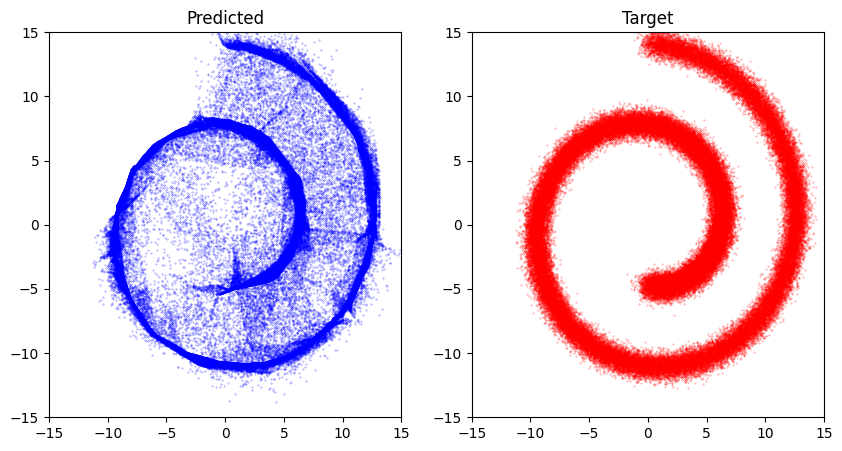

In [72]:
fig, ax = plt.subplots(1, 2, figsize=(10, 5))
ax[0].scatter(pred[:, 0], pred[:, 1], color="blue", alpha=0.5, s=0.1)
ax[0].set_xlim(-15, 15)
ax[0].set_ylim(-15, 15)
ax[0].set_title("Predicted")
ax[1].scatter(swiss_roll_dist[:, 0], swiss_roll_dist[:, 1], color="red", alpha=0.5, s=0.1)
ax[1].set_xlim(-15, 15)
ax[1].set_ylim(-15, 15)
ax[1].set_title("Target")
plt.show()